## imports


In [1]:
print(f"hello world")

hello world


In [2]:
import copy
import os
import sys
import matplotlib.pyplot as plt
import torch
import json
import pickle
from itertools import chain
import selfeeg

from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from mne_connectivity import spectral_connectivity_time
from sklearn.metrics import balanced_accuracy_score

import warnings
warnings.filterwarnings("ignore", message="Using padding='same'", category=UserWarning)

In [3]:
dir_base = Path("../..")
print(os.path.abspath(dir_base))

sys.path.append(os.path.abspath(dir_base))


/home/mgrabner/eeglass2/all-in-on-eeg


In [110]:
%load_ext autoreload
%autoreload 2

# from shallownetXAI_main.AllFnc.models import ShallowNet, ShallowNet2

from backend.ml.shallownet_utils import lossBinary, lossMulti, train_model
from backend.ml.shallownet_utils_dev import get_performances


from backend.ml.data_utils.load_data import *
from backend.ml.data_utils.prepare_data import *
from backend.experiments_xeegnet.xeegnet_with_conn import xEEGNetSCC


from backend.ml.model_vars import PRETRAINED_MODEL_DIR
from backend.ml.train import train_save_model, get_train_val_test_loader, PARAMETERS_DEFAULT, TRAINING_PARAMETERS_DEFAULT, save_model, load_model_weights
from main import load_participant_splits

from backend.ml.scc_cache import SCCStore, SCCParams, build_x_y_scc, CachedSCCDataset, SCCReducer, pairs_to_dense
from backend.experiments_xeegnet.model_evaluations import get_dataloaders_xysubjectids, split_data
from model_evaluations import get_dataloaders_xysubjectids, split_data, generate_model_name, MODEL_PREFIXES_BIB, filter_results_dataframe


from xeegnet_with_conn import BANDS


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### paths


In [5]:
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")
dir_data_abs = os.path.abspath(dir_data)
data_path = os.path.join(dir_data, "sub-001", "eeg", "sub-001_task-eyesclosed_eeg.set")

dir_data_outer = os.path.join(dir_base, "data")

dir_shallownetXAI = os.path.join(
    dir_base, "backend", "experiments_xeegnet", "shallownetXAI_main"
)

# data_path = os.path.join(dir_data_abs, 'ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set')

#### settings


In [6]:
pipelineToEval = "filt"  #'icasr'
# taskToEval = "alzheimer"
# modelToEval = "shallownet_custom"  # shallownet, shallownet_custom

task = "three_class"  # "two_class"  # "three_class
task = "cn_ad"
task = "cn_ftd"
task = "cn_disease"

nb_classes = 3 if task == "three_class" else 2

# outFold = 1
# inFold = 5
# overlap = 0.0
# workers = 0

lr = 5 * 10 ** (-5)
# epochs = 1000

downsample = True
z_score = True
rem_interp = True
batchsize = 64


window = 4
verbose = True

# lossVal = None
seed = 83136297

Chans = 19
srate = 125 if downsample else 250

sample_length = 125 * 4  # srate * window

# SET DEVICE: 0 = ZANOLA
if torch.cuda.is_available():
    device = torch.device(0)
else:
    device = torch.device("cpu")
print(device)

cpu


# Read Data


In [7]:
df_metadata = load_metadata(dir_data)

In [8]:
df_metadata.head(2)

,participant_id,Gender,Age,Group,MMSE,group_long,group_encoded,participant_id_int
0,sub-001,F,57,A,16,Alzheimer Disease Group,1,1
1,sub-002,F,78,A,22,Alzheimer Disease Group,1,2


In [9]:
# participant_ids = [2,3]

# 4 - 88
participant_ids = np.arange(1,89).tolist()
print(participant_ids)
# participant_ids

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88]


In [10]:
path=Path(dir_data_outer) / "scc_cache" / "ds004504" / "derivatives" 

store  = SCCStore(
    root=Path(dir_data_outer) / "scc_cache" 
)
scc_params = SCCParams.default(sfreq=srate, sample_length=sample_length)

## Built Models


### xeegnet + spectral connectivity


In [11]:
def build_xeegnet_scc(nb_classes=3, Chans=19, Samples=125 * 4, Fs=125):
    base = selfeeg.models.xEEGNet(
        nb_classes=3,
        Chans=19,
        Samples=125 * 4,
        Fs=125,
        global_pooling=True,
    )
    # Wrapper with cached spectral connectivity pairs
    xeegnet_scc = xEEGNetSCC(base_model=base, reducer_mode_scc="mean")
    return xeegnet_scc

In [12]:
# Base xEEGNet
base = selfeeg.models.xEEGNet(
    nb_classes=3,
    Chans=19,
    Samples=125 * 4,
    Fs=125,
    global_pooling=True,
 )
# Wrapper with cached spectral connectivity pairs
xeegnet_scc = xEEGNetSCC(base_model=base, reducer_mode_scc="mean")


### Other Models


In [13]:
xeegnet = selfeeg.models.xEEGNet(
    nb_classes=nb_classes,
    Chans=Chans,
    Samples=sample_length,
    Fs=125 if downsample else 250,
    global_pooling=True,
)

#### Test forward pass


In [14]:
n_batches = 10

x = torch.randn(n_batches, Chans, sample_length, dtype=torch.float32)
scc_pairs = torch.randn(n_batches, len(BANDS), Chans*(Chans-1)//2, dtype=torch.float32)

out = xeegnet_scc([x, scc_pairs])
print(out.shape)  # shoud return torch.Size([3, 3])
print(torch.isnan(out).sum())  # shoud return 0
out

torch.Size([10, 3])
tensor(0)


tensor([[ 0.9202, -0.3118, -0.9181],
        [-0.9743, -0.0461,  0.5507],
        [-0.1577, -1.1345,  0.7761],
        [ 0.0542, -0.0374,  0.7085],
        [ 0.8372,  0.2081, -0.9808],
        [-0.8139,  0.2655,  1.1328],
        [ 0.2404,  0.4724, -1.1022],
        [ 0.7861,  0.3392,  0.0445],
        [-0.2359,  0.5481, -0.6103],
        [-0.0685,  0.2071, -0.6565]], grad_fn=<MmBackward0>)

In [15]:
out = xeegnet(x)
print(out.shape)  # shoud return torch.Size([3, 3])
out

torch.Size([10, 1])


tensor([[ 0.7983],
        [-0.7424],
        [-0.3459],
        [ 0.1671],
        [ 0.9699],
        [ 0.7691],
        [ 0.2429],
        [ 1.0550],
        [ 0.0575],
        [ 0.0920]], grad_fn=<MmBackward0>)

# train models


### functions


In [22]:
# def _predict_from_loader_with_ids(model, loader, device):
#     """For loaders whose dataset returns (X, y, sid). Ids travel with each sample,
#     so this is correct even when shuffle=True."""
#     model.eval()
#     y_true_all, y_pred_all, sids_all = [], [], []
#     with torch.no_grad():
#         for inputs, targets, sids in loader:
#             if isinstance(inputs, (list, tuple)):
#                 outputs = model([inputs[0].to(device), inputs[1].to(device)])
#             else:
#                 outputs = model(inputs.to(device))
#             if outputs.shape[1] == 1:
#                 preds = (outputs.squeeze(1) > 0).long()
#             else:
#                 preds = torch.argmax(outputs, dim=1)
#             y_true_all.extend(targets.detach().cpu().numpy().tolist())
#             y_pred_all.extend(preds.detach().cpu().numpy().tolist())
#             sids_all.extend(sids.detach().cpu().numpy().tolist())

#     return np.asarray(y_true_all), np.asarray(y_pred_all), np.asarray(sids_all)


def _predict_from_loader_with_ids(model, loader, device, subject_ids):
    """subject_ids: per-split id array aligned to the loader's order (shuffle=False)."""
    y_true, y_pred = _predict_from_loader(model, loader, device)   # 2-tuple loaders
    sids = np.asarray(subject_ids)
    if len(sids) != len(y_true):
        raise ValueError(f"subject_ids ({len(sids)}) != predictions ({len(y_true)}) — split misaligned.")
    return y_true, y_pred, sids
    


def aggregate_subject_predictions(y_true, y_pred, subject_ids, nb_classes):
    """Collapse window predictions to one prediction per subject by majority vote.
    Returns (subj_true, subj_pred, subject_order) as arrays aligned by subject."""
    subject_order = np.unique(subject_ids)
    subj_true, subj_pred = [], []
    for sid in subject_order:
        m = subject_ids == sid
        true_vals = y_true[m]
        if not np.all(true_vals == true_vals[0]):        # alignment guard
            raise ValueError(f"Subject {sid} has mixed true labels {np.unique(true_vals)} — sids/y misaligned.")
        subj_true.append(int(true_vals[0]))
        # majority vote over window predictions; bincount ties -> lowest class (deterministic)
        counts = np.bincount(y_pred[m].astype(int), minlength=nb_classes)
        subj_pred.append(int(counts.argmax()))
    return np.asarray(subj_true), np.asarray(subj_pred), subject_order


# def evaluate_subject_level(model, loader, device, nb_classes, result_base, datasplit):
#     """Per-subject metrics via majority voting. Returns one row, same metric columns
#     as the window-level rows, tagged aggregation='subject_majority'."""
#     y_true, y_pred, sids = _predict_from_loader_with_ids(model, loader, device)
#     subj_true, subj_pred, subject_order = aggregate_subject_predictions(y_true, y_pred, sids, nb_classes)
#     return {
#         **result_base,
#         "datasplit": datasplit,
#         "aggregation": "subject_majority",
#         "n_samples": len(subject_order),          # now #subjects, not #windows
#         **_compute_metrics(subj_true, subj_pred),
#     }

In [23]:
def build_model_for_version(model_kind: str, nb_classes: int, Chans: int, sample_length: int, srate: int, reducer_mode_scc: str = "mean", seed: int = 42):
    """
    reducer mode:
        "mean"   -> average SCC across pairs for each band (default)
        "node"   -> weighted sum of 19 channels (7x19 weights)
        "edge"   -> weight for each of the 171 pairs (7x171 weights)
    """

    np.random.seed(seed)
    torch.manual_seed(seed)

    model_kind = model_kind.casefold()
    if model_kind == "xeegnet_scc":
        base_model = selfeeg.models.xEEGNet(
            nb_classes=nb_classes,
            Chans=Chans,
            Samples=sample_length,
            Fs=srate,
            global_pooling=True,
            return_logits=True
        )
        return xEEGNetSCC(base_model=base_model, reducer_mode_scc=reducer_mode_scc)
    if model_kind == "xeegnet":
        return selfeeg.models.xEEGNet(
            nb_classes=nb_classes,
            Chans=Chans,
            Samples=sample_length,
            Fs=srate,
            global_pooling=True,
        )
    # if model_kind == "shallownet":
    #     return ShallowNet(nb_classes=nb_classes, Chans=Chans, Samples=sample_length, seed=seed)
    # raise ValueError(f"Unsupported model_kind: {model_kind}")


def _predict_from_loader(model, loader, device):
    model.eval()
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for inputs, targets in loader:
            targets_np = targets.detach().cpu().numpy()
            if isinstance(inputs, (list, tuple)):
                x_batch = inputs[0].to(device)
                scc_batch = inputs[1].to(device)
                outputs = model([x_batch, scc_batch])
            else:
                outputs = model(inputs.to(device))

            if outputs.shape[1] == 1:                      # single-logit (binary) head
                predictions = (outputs.squeeze(1) > 0).long()   # logit > 0  ==  sigmoid > 0.5
            else:                                          # multi-logit head
                predictions = torch.argmax(outputs, dim=1)
                
            y_true_all.extend(targets_np.tolist())
            y_pred_all.extend(predictions.tolist())

    return np.asarray(y_true_all), np.asarray(y_pred_all)


def _compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def _prepare(
    model_version, model_kind, reducer_mode_scc, *,
    dir_data, dir_data_outer, parameters, nb_classes, Chans, sample_length, srate,
    device, n_max, store, scc_params, load_model_windows_for_participant,
    data_x_y_id, data_x_y_scc_id, model_seed, shuffle_train=True, return_subject_ids=False
):
    """Shared setup: split lookup, metadata, model, loaders, canonical name.

    Both entry points go through this so they can never disagree on how the
    model, loaders, or checkpoint name are built.
    """
    split_index = model_version - 200
    split_path = Path(dir_base) / "backend" / "ml" / "data_splits.json"
    participants_split = load_participant_splits(split_path=split_path)[str(split_index)]

    df_metadata = load_metadata(dir_data=dir_data)
    df_metadata["datasplit"] = "test"
    df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["train"]), "datasplit"] = "train"
    df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["val"]), "datasplit"] = "val"

    model = build_model_for_version(
        model_kind, nb_classes, Chans, sample_length, srate, reducer_mode_scc, seed=model_seed
    ).to(device)

    if model_kind.casefold() == "xeegnet_scc":
        if load_model_windows_for_participant is None:
            load_model_windows_for_participant = globals().get("load_model_windows_for_participant")
        if load_model_windows_for_participant is None:
            raise ValueError("load_model_windows_for_participant is required for xeegnet_scc.")
        if store is None:
            store = SCCStore(root=Path(dir_data_outer) / "scc_cache")
        if scc_params is None:
            scc_params = SCCParams.default(sfreq=srate, sample_length=sample_length)

        trainloader, valloader, testloader, xy = get_dataloaders_xysubjectids(
            dir_data=dir_data,
            participant_ids_train=participants_split["train"],
            participant_ids_val=participants_split["val"],
            participant_ids_test=participants_split["test"],
            df_metadata=df_metadata, parameters=parameters, n_max=n_max,
            use_cached_scc=True, store=store, scc_params=scc_params,
            dataset_id="ds004504", n_channels=Chans, source="derivatives",
            load_model_windows_for_participant=load_model_windows_for_participant,
            data_x_y_id=data_x_y_id, data_x_y_scc_id=data_x_y_scc_id, shuffle_train=shuffle_train
        )
    else:
        trainloader, valloader, testloader, xy = get_dataloaders_xysubjectids(
            dir_data=dir_data,
            participant_ids_train=participants_split["train"],
            participant_ids_val=participants_split["val"],
            participant_ids_test=participants_split["test"],
            df_metadata=df_metadata, 
            parameters=parameters, 
            n_max=n_max,
            use_cached_scc=False, 
            data_x_y_id=data_x_y_id, 
            data_x_y_scc_id=data_x_y_scc_id, 
            shuffle_train=shuffle_train
        )

    # if model_kind.casefold() == "xeegnet_scc":
    #     _, _, subject_ids_train, _, _, _, subject_ids_val, _, _, _, subject_ids_test, _= xy
    # elif model_kind.casefold() == "xeegnet":
    #     _, _, subject_ids_train, _, _, subject_ids_val, _, _, subject_ids_test = xy
    # subject_ids = {"train": subject_ids_train, "val": subject_ids_val, "test": subject_ids_test}


    model_name = generate_model_name(model_kind, model_version, n_max, reducer_mode_scc)
    loaders = {"train": trainloader, "val": valloader, "test": testloader}
    if return_subject_ids:
        if model_kind.casefold() == "xeegnet_scc":
            _, _, subject_ids_train, _, _, subject_ids_val, _, _, _, _, subject_ids_test, _= xy
        elif model_kind.casefold() == "xeegnet":
            _, _, subject_ids_train, _, _, subject_ids_val, _, _, subject_ids_test = xy
        subject_ids = {"train": subject_ids_train, "val": subject_ids_val, "test": subject_ids_test}
        return model, loaders, model_name, subject_ids
    else:
        return model, loaders, model_name


def _evaluate_splits(model, loaders, eval_datasplits, result_base, *, device, nb_classes, plot_confusion=False, subject_ids=None):
    """Evaluate on each split. Emits a 'window' row per split, plus a
    'subject_majority' row when subject_ids aggregation is requested.
    Ids ride with each sample (dataset returns them), so this is correct
    even for the shuffled train loader."""
    rows = []
    for datasplit in eval_datasplits:
        if subject_ids is not None:
            y_true, y_pred, sids = _predict_from_loader_with_ids(
                model, loaders[datasplit], device, subject_ids[datasplit]          # 3 args — ids come from batches
            )
        else:
            y_true, y_pred = _predict_from_loader(model, loaders[datasplit], device)
            sids = None

        rows.append({
            **result_base, "datasplit": datasplit, "aggregation": "window",
            "n_samples": len(y_true), **_compute_metrics(y_true, y_pred),
        })

        if sids is not None:
            subj_true, subj_pred, _ = aggregate_subject_predictions(y_true, y_pred, sids, nb_classes)
            rows.append({
                **result_base, "datasplit": datasplit, "aggregation": "subject_majority",
                "n_samples": len(subj_true), **_compute_metrics(subj_true, subj_pred),
            })

    if plot_confusion:
        get_performances(
            loader2eval=loaders["test"], Model=model, device=device, nb_classes=nb_classes,
            return_scores=False, verbose=False, plot_confusion=True,
            class_labels=[f"Class {i}" for i in range(nb_classes)],
        )
    return rows


In [52]:
def train_model_version(
    model_version: int,
    task: str,
    model_kind: str = "xeegnet_scc",
    reducer_mode_scc: str = "mean",
    *,
    dir_data: str = dir_data, 
    dir_data_outer: str = dir_data_outer,
    parameters: dict = PARAMETERS_DEFAULT, 
    nb_classes: int = nb_classes,
    Chans: int = Chans, 
    sample_length: int = sample_length, 
    srate: int = srate,
    device: torch.device = device, 
    lr: float = lr, 
    verbose: bool = verbose,
    # task_to_eval: str = taskToEval, 
    n_max: int | None = None,
    train_epochs: int = 100, 
    save_model_flag: bool = True,
    store: SCCStore | None = None, 
    scc_params: SCCParams | None = None,
    load_model_windows_for_participant=None,
    data_x_y_id=None, data_x_y_scc_id=None,
    do_evaluate: bool = True, 
    eval_datasplits: list[str] = ("test",), 
    model_seed: int = 42,
):
    """Prepare, train, save, and optionally evaluate a model version. Returns rows."""
    model, loaders, model_name = _prepare(
        model_version,
        model_kind,
        reducer_mode_scc,
        dir_data=dir_data,
        dir_data_outer=dir_data_outer,
        parameters=parameters,
        nb_classes=nb_classes,
        Chans=Chans,
        sample_length=sample_length,
        srate=srate,
        device=device,
        n_max=n_max,
        store=store,
        scc_params=scc_params,
        load_model_windows_for_participant=load_model_windows_for_participant,
        data_x_y_id=data_x_y_id,
        data_x_y_scc_id=data_x_y_scc_id,
        model_seed=model_seed,
        return_subject_ids=False
    )

    loss_fnc = lossMulti if nb_classes > 2 else lossBinary
    if verbose:
        print(f"Using loss function: {loss_fnc.__name__} for {nb_classes} classes.")

    earlystop_local = selfeeg.ssl.EarlyStopping(patience=15, min_delta=1e-04, record_best_weights=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.995)

    loss_info = train_model(
        model=model,
        train_dataloader=loaders["train"],
        epochs=train_epochs,
        optimizer=optimizer,
        loss_func=loss_fnc,
        lr_scheduler=scheduler,
        EarlyStopper=earlystop_local,
        validation_dataloader=loaders["val"],
        # validation_loss_func=lossVal,
        validation_loss_args=validation_loss_args,
        verbose=verbose,
        device=device,
        return_loss_info=True,
    )

    model_path = generate_model_path(PRETRAINED_MODEL_DIR, task, model_name)
    if verbose:
        print(f"Model path: {model_path}")
    # model_path = PRETRAINED_MODEL_DIR / model_name
    if save_model_flag:
        save_model(model, model_path)

    result_base = {
        "model_version": model_version,
        "model_kind": model_kind,
        "reducer_mode_scc": reducer_mode_scc,
        "model_name": model_name,
        "model_path": str(model_path),
        "train_epochs": train_epochs,
        "loss_info": loss_info,
        "task": task
    }
    if do_evaluate:
        return _evaluate_splits(
            model,
            loaders,
            list(eval_datasplits),
            result_base,
            device=device,
            nb_classes=nb_classes,
        )
    return [result_base]

In [53]:
def evaluate_model_version(
    model_version: int,
    model_kind: str,
    reducer_mode_scc: str,
    model_path_loading: str,
    task: str = "None",
    *,
    dir_data: str = dir_data, 
    dir_data_outer: str = dir_data_outer,
    parameters: dict = PARAMETERS_DEFAULT, 
    nb_classes: int = nb_classes,
    Chans: int = Chans, 
    sample_length: int = sample_length, 
    srate: int = srate,
    device: torch.device = device, 
    verbose: bool = verbose,
    # task_to_eval: str = taskToEval, n_max: int | None = None,
    store: SCCStore | None = None, 
    scc_params: SCCParams | None = None,
    load_model_windows_for_participant=None,
    data_x_y_id=None, 
    data_x_y_scc_id=None,
    eval_datasplits: list[str] = ("test",), 
    model_seed: int = 42, 
    n_max: int | None = None
):
    """Prepare, load checkpoint weights, and evaluate. Returns rows.

    Loading is the body, not a branch, so it can never be silently skipped.
    """
    model, loaders, model_name, subject_ids = _prepare(
        model_version, 
        model_kind, 
        reducer_mode_scc,
        dir_data=dir_data,
        dir_data_outer=dir_data_outer, 
        parameters=parameters,
        nb_classes=nb_classes, 
        Chans=Chans, 
        sample_length=sample_length, 
        srate=srate,
        device=device, 
        n_max=n_max, 
        store=store, 
        scc_params=scc_params,
        load_model_windows_for_participant=load_model_windows_for_participant,
        data_x_y_id=data_x_y_id, 
        data_x_y_scc_id=data_x_y_scc_id, 
        model_seed=model_seed,
        shuffle_train=False,
        return_subject_ids=True
    )

    if model_path_loading is None or not Path(model_path_loading).is_file():
        raise FileNotFoundError(f"No checkpoint to evaluate at {model_path_loading}")
    model = load_model_weights(model_path=model_path_loading, model=model, device=device, verbose=False)

    result_base = {
        "model_version": model_version, 
        "model_kind": model_kind,
        "reducer_mode_scc": reducer_mode_scc, 
        "model_name": model_name,
        "model_path": str(model_path_loading), 
        "task": task,
        "train_epochs": None,
    }
    return _evaluate_splits(model, loaders, list(eval_datasplits), result_base, device=device, nb_classes=nb_classes, subject_ids=subject_ids)

In [55]:
def adapt_data_for_task(data_x_y_scc_id, task):
    """Filter subjects and remap labels for a classification task.
    SCC is label-independent, so this only subsets rows — no recompute."""
    x, y, scc, sids = data_x_y_scc_id

    if task == "three_class":
        return x.copy(), y.copy(), scc.copy(), sids.copy()

    if task == "cn_ad":
        mask = np.isin(y, [0, 1])
        y_new = np.where(y[mask] == 1, 1, 0)        # AD -> 1, CN -> 0
    elif task == "cn_ftd":
        mask = np.isin(y, [0, 2])
        y_new = np.where(y[mask] == 2, 1, 0)        # FTD -> 1, CN -> 0
    elif task == "cn_disease":
        mask = np.ones(len(y), dtype=bool)          # keep all
        y_new = (y[mask] > 0).astype(int)           # any dementia -> 1
    else:
        raise ValueError(f"Unsupported task: {task}")

    y_new = y_new.astype("float32")                 # BCE-with-logits needs float
    return x[mask], y_new, scc[mask], sids[mask]

In [56]:
def generate_model_path(pretrained_model_dir, task, name):
    """Generate a model path based on the task and name."""

    if task == "three_class":
        return Path(pretrained_model_dir) / name
    else:
        return Path(pretrained_model_dir) / task / name

### Running


In [28]:
source = "derivatives"
dataset_id = "ds004504"

label_of = {
    f"sub-{int(r.participant_id.split('-')[1]):03d}": int(r.group_encoded)
    for r in df_metadata.itertuples()
}

x, y, scc, data_subject_ids = build_x_y_scc(
    dir_data=dir_data,
    participant_ids=participant_ids,
    label_of_subject=label_of,
    store=store,
    params=scc_params,
    load_model_windows_for_participant=load_model_windows_for_participant,
    dataset_id=dataset_id,
    n_channels=Chans,
    source=source,
    sample_length=sample_length,
    n_jobs=1,
    print_info=True,
)

data_x_y_scc_id = (x, y, scc, data_subject_ids)
# data_x_y_id = (x, y, data_subject_ids)

  cache hit for sub-001 (derivatives) -> (149, 7, 171)
  cache hit for sub-002 (derivatives) -> (198, 7, 171)
  cache hit for sub-003 (derivatives) -> (76, 7, 171)
  cache hit for sub-004 (derivatives) -> (176, 7, 171)
  cache hit for sub-005 (derivatives) -> (201, 7, 171)
  cache hit for sub-006 (derivatives) -> (158, 7, 171)
  cache hit for sub-007 (derivatives) -> (191, 7, 171)
  cache hit for sub-008 (derivatives) -> (198, 7, 171)
  cache hit for sub-009 (derivatives) -> (153, 7, 171)
  cache hit for sub-010 (derivatives) -> (320, 7, 171)
  cache hit for sub-011 (derivatives) -> (192, 7, 171)
  cache hit for sub-012 (derivatives) -> (220, 7, 171)
  cache hit for sub-013 (derivatives) -> (209, 7, 171)
  cache hit for sub-014 (derivatives) -> (233, 7, 171)
  cache hit for sub-015 (derivatives) -> (225, 7, 171)
  cache hit for sub-016 (derivatives) -> (243, 7, 171)
  cache hit for sub-017 (derivatives) -> (210, 7, 171)
  cache hit for sub-018 (derivatives) -> (211, 7, 171)
  cache hit

In [70]:
def evaluate_saved_model(model_path, model_kind, nb_classes, task, reducer_mode_scc="mean", model_version=None, data_x_y_scc_id=data_x_y_scc_id, eval_datasplits=["train", "val", "test"]):
    """Convenience wrapper: bind notebook globals and evaluate a saved checkpoint."""
    model_path = Path(model_path)
    if model_version is None:   # fallback; prefer passing it from the run dict
        model_version = int(model_path.stem.split("_v")[-1].split("_")[0])

    print(f"-- Evaluating task {task} for {model_kind} v{model_version} (reducer={reducer_mode_scc}) at {model_path} --")

    return evaluate_model_version(
        model_version=model_version,
        model_kind=model_kind,
        reducer_mode_scc=reducer_mode_scc,
        model_path_loading=model_path,
        dir_data=dir_data,
        dir_data_outer=dir_data_outer,
        parameters=PARAMETERS_DEFAULT,
        nb_classes=nb_classes,
        Chans=Chans,
        sample_length=sample_length,
        srate=srate,
        device=device,
        verbose=verbose,
        task=task,

        # task_to_eval=taskToEval,
        # n_max=None,
        store=store,
        scc_params=scc_params,
        load_model_windows_for_participant=load_model_windows_for_participant,
        data_x_y_scc_id=data_x_y_scc_id,
        eval_datasplits=eval_datasplits,
    )

In [58]:
if False:
    model, loaders, name, subject_ids = _prepare(..., data_x_y_scc_id=data_x_y_scc_id_new)
    yt, yp = _predict_from_loader(model, loaders["test"], device)
    ids = np.asarray(subject_ids["test"])

    # For each window position, does the loader's true label match the id's known label?
    x, y_all, scc, sids_all = data_x_y_scc_id_new
    label_of_subject = {int(s): int(y_all[sids_all == s][0]) for s in np.unique(sids_all)}
    expected = np.array([label_of_subject[int(s)] for s in ids])
    print("positions where loader y != expected-from-id:", np.sum(yt != expected))
    print("first mismatch idx:", np.argmax(yt != expected))

    model, loaders, name, subject_ids = _prepare(
        200, "xeegnet_scc", "node",
        dir_data=dir_data, dir_data_outer=dir_data_outer, parameters=PARAMETERS_DEFAULT,
        nb_classes=nb_classes, Chans=Chans, sample_length=sample_length, srate=srate,
        device=device, n_max=None, store=store, scc_params=scc_params,
        load_model_windows_for_participant=load_model_windows_for_participant,
        data_x_y_id=None, data_x_y_scc_id=data_x_y_scc_id_new, model_seed=0, shuffle_train=False, return_subject_ids=True
    )
    yt, yp = _predict_from_loader(model, loaders["test"], device)
    ids = np.asarray(subject_ids["test"])

    # For each window position, does the loader's true label match the id's known label?
    x, y_all, scc, sids_all = data_x_y_scc_id_new
    label_of_subject = {int(s): int(y_all[sids_all == s][0]) for s in np.unique(sids_all)}
    expected = np.array([label_of_subject[int(s)] for s in ids])
    print("positions where loader y != expected-from-id:", np.sum(yt != expected))
    print("first mismatch idx:", np.argmax(yt != expected))

    model, loaders, name, subject_ids = _prepare(
    200, "xeegnet_scc", "node",
    dir_data=dir_data, dir_data_outer=dir_data_outer, parameters=PARAMETERS_DEFAULT,
    nb_classes=nb_classes, Chans=Chans, sample_length=sample_length, srate=srate,
    device=device, n_max=None, store=store, scc_params=scc_params,
    load_model_windows_for_participant=load_model_windows_for_participant,
    data_x_y_id=None, data_x_y_scc_id=data_x_y_scc_id_new, model_seed=0, shuffle_train=False, return_subject_ids=True
)
    yt, yp = _predict_from_loader(model, loaders["train"], device)
    ids = np.asarray(subject_ids["train"])

    # For each window position, does the loader's true label match the id's known label?
    x, y_all, scc, sids_all = data_x_y_scc_id_new
    label_of_subject = {int(s): int(y_all[sids_all == s][0]) for s in np.unique(sids_all)}
    expected = np.array([label_of_subject[int(s)] for s in ids])
    print("positions where loader y != expected-from-id:", np.sum(yt != expected))
    print("first mismatch idx:", np.argmax(yt != expected))


In [59]:
data_x_y_scc_id_backup = copy.deepcopy(data_x_y_scc_id)

In [60]:
n_max = None
max_epochs = 200

do_evaluate = True
save_model_flag = True

scc_params = SCCParams.default(sfreq=srate, sample_length=sample_length)
parameters = PARAMETERS_DEFAULT
training_parameters = TRAINING_PARAMETERS_DEFAULT
validation_loss_args = []

task = "three_class"

In [61]:
if False:

    model_versions = range(200, 202)
    
    multi_model_results = []
    for model_version in model_versions:
        run_rows = train_model_version(
            model_version=model_version,
            model_kind="xeegnet_scc",
            # reducer_mode_scc=reducer_mode_scc,           # <-- was missing; else it defaults to "mean"
            train_epochs=max_epochs, 
            save_model_flag=save_model_flag,
            n_max=n_max, 
            store=store, 
            scc_params=scc_params,
            load_model_windows_for_participant=load_model_windows_for_participant,
            data_x_y_scc_id=data_x_y_scc_id,
            do_evaluate=do_evaluate,
            eval_datasplits=["train", "val", "test"],
            # eval_datasplits=eval_datasplits,
        )

        multi_model_results.extend(run_rows)             # extend, not append

    results_df = pd.DataFrame(multi_model_results).sort_values(["model_version", "reducer_mode_scc", "datasplit"]).reset_index(drop=True)

    # print(results_df)

    metrics_csv_path = PRETRAINED_MODEL_DIR / "xeegnet_scc_model_versions_200_204_metrics.csv"
    # results_df.to_csv(metrics_csv_path, index=False)
    # print(f"Saved metrics to {metrics_csv_path}")

    results_df

### Evaluate models


In [ ]:
if False:
    model_versions = [200, 201, 202, 203, 204]
    model_versions = [200]
    # model_versions = [200, 201]
    model_kinds = ["xeegnet", "xeegnet_scc"]

    eval_datasplits = ["test"]
    results_name = "xeegnet_scc_model_versions_200_204_metrics.csv"

    eval_datasplits = ["test", "val", "train"]
    results_name = "xeegnet_scc_model_versions_200_204_metrics_allsplits.csv"

    saved_model_runs = []

    for model_version in model_versions:
        for model_kind in model_kinds:
            model_prefix = MODEL_PREFIXES_BIB[model_kind]

            model_name = generate_model_name(model_kind, model_version, n_max=None, reducer_mode_scc="mean")
            model_path = generate_model_path(PRETRAINED_MODEL_DIR, task, model_name)

            saved_model_runs.append(
                {
                    "model_kind": model_kind,
                    "model_path": model_path,
                    # "model_path": PRETRAINED_MODEL_DIR / "pretrained_models_local_backup"  /  f"{model_prefix}_v{model_version}.pt",
                }
            )

    saved_model_results = []
    for run in saved_model_runs:
        saved_model_results.extend(evaluate_saved_model(run["model_path"], run["model_kind"]))

    saved_model_results_df = (
        pd.DataFrame(saved_model_results)
        .sort_values(["model_version", "model_kind", "datasplit"])
        .reset_index(drop=True)
    )

    saved_model_results_name = PRETRAINED_MODEL_DIR / results_name
    # saved_model_results_df.to_csv(saved_model_results_name, index=False)
    saved_model_results_df

### reducer mode node


In [63]:
possible_tasks = ["cn_ad", "cn_ftd", "cn_disease", "three_class"]

# task = "cn_disease"  # Alzheimer's disease vs. control
# nb_classes = 3 if task == "three_class" else 2

# data_x_y_scc_id_new = adapt_data_for_task(data_x_y_scc_id, task)

In [38]:
debug = False
save_results_df_flag = True

if debug:
    # n_max_ = 500
    n_max_ = None
    max_epochs_ = 1
    save_model_flag_ = False

    save_results_df_flag = False

else:
    n_max_ = None
    max_epochs_ = max_epochs
    save_model_flag_ = True


# reducer_mode_scc_list = ["mean", "node", "edge"]

reducer_mode_scc_list = ["node", "mean", "edge"]
# results_name = f"xeegnet_scc_reducer_modes_model_versions_200_204_metrics.csv"
# model_kind = "xeegnet_scc"

model_kind_list = ["xeegnet", "xeegnet_scc"]
# model_kind_list = ["xeegnet", "xeegnet_scc"]
# model_kind = "xeegnet"

model_versions = [200, 201, 202, 203, 204]
# model_versions = [200, 201]

i = 0
model_seed = 0

# tasks = ["cn_ad", "cn_ftd", "cn_disease"]
# tasks = ["cn_disease"]
tasks = ["cn_ad", "cn_ftd"]

if False:
    for task in tasks:
        print(f"Running task: {task}")
        data_x_y_scc_id_new = adapt_data_for_task(data_x_y_scc_id, task)
        results_name = f"{task}_xeegnet_scc_reducer_modes_model_versions_200_204_metrics.csv"

        multi_model_results = []
        for model_kind in model_kind_list:
            modes = reducer_mode_scc_list if model_kind == "xeegnet_scc" else [None]
            for reducer_mode_scc in modes:
                for model_version in model_versions:

                    print(f"Training and evaluating model version: {model_version} - modeltype: {model_kind} - reducer_mode_scc: {reducer_mode_scc}, model {i}/{len(reducer_mode_scc_list) * len(model_versions)}")

                    run_rows = train_model_version(
                        model_version=model_version,
                        model_kind=model_kind,
                        reducer_mode_scc=reducer_mode_scc,
                        train_epochs=max_epochs_, 
                        save_model_flag=save_model_flag_,
                        n_max=n_max_, 
                        store=store, 
                        scc_params=scc_params,
                        task=task,
                        load_model_windows_for_participant=load_model_windows_for_participant,
                        data_x_y_scc_id=data_x_y_scc_id_new,
                        do_evaluate=do_evaluate,
                        eval_datasplits=["train", "val", "test"],
                        model_seed=model_seed,
                        verbose=True
                    )
                    
                    multi_model_results.extend(run_rows)             # extend, not append

                    i += 1

        results_df = pd.DataFrame(multi_model_results).sort_values(["model_version", "reducer_mode_scc", "datasplit"]).reset_index(drop=True)

        if save_results_df_flag:
            metrics_csv_path = PRETRAINED_MODEL_DIR / results_name
            results_df.to_csv(metrics_csv_path, index=False)
            print(f"Saved metrics to {metrics_csv_path}")


In [39]:
results_df

NameError: name 'results_df' is not defined

evaluate models with different reducer modes

In [40]:
# possible_tasks = ["cn_ad", "cn_ftd", "cn_disease", "three_class"]

# task = "cn_disease"  # Alzheimer's disease vs. control
# nb_classes = 3 if task == "three_class" else 2


# data_x_y_scc_id_new = adapt_data_for_task(data_x_y_scc_id, task)

In [66]:
dir_results = Path(dir_base) / "backend" / "experiments_xeegnet" / "results"

In [ ]:
save_results_flag = True

# model_versions = [200]
# model_versions = [200, 201]

# # model_kinds = ["xeegnet_scc"] #, "xeegnet"
# reducer_mode_scc_list = ["node", "mean"]

# eval_datasplits = ["test"]


eval_datasplits = ["test", "val", "train"] #, "val", "train"
model_kind_list = ["xeegnet", "xeegnet_scc"] 
reducer_mode_scc_list = ["mean", "node", "edge"]
model_versions = [200, 201, 202, 203, 204]
tasks = ["cn_ad", "cn_ftd", "cn_disease", "three_class"]

# results_name = "xeegnet_scc_model_versions_200_204_metrics_v2.csv"
result_name = "xeegnet_scc_model_versions_200_204_metrics_alltasks.csv"

saved_model_runs = []
for task in tasks:
    data_x_y_scc_id_taskadapted = adapt_data_for_task(data_x_y_scc_id, task)
    nb_classes = 3 if task == "three_class" else 2

    for model_version in model_versions:
        for model_kind in model_kind_list:

            modes = reducer_mode_scc_list if model_kind == "xeegnet_scc" else [None]

            
            for reducer_mode_scc in modes:
                model_prefix = MODEL_PREFIXES_BIB[model_kind]

                model_name = generate_model_name(model_kind, model_version, n_max=None, reducer_mode_scc=reducer_mode_scc)
                model_path = generate_model_path(PRETRAINED_MODEL_DIR, task, model_name)
            
                saved_model_runs.append(
                    {
                        "model_kind": model_kind,
                        "model_path": model_path,
                        # "model_path": PRETRAINED_MODEL_DIR / "pretrained_models_local_backup"  /  f"{model_prefix}_v{model_version}.pt",
                        "reducer_mode_scc": reducer_mode_scc,
                        "task": task,
                        "nb_classes": nb_classes,
                        "dataset": data_x_y_scc_id_taskadapted
                    }
                )

saved_model_results = []
for run in saved_model_runs:
    saved_model_results.extend(evaluate_saved_model(run["model_path"], 
                                                    run["model_kind"], 
                                                    reducer_mode_scc=run["reducer_mode_scc"], 
                                                    task=run["task"],
                                                    data_x_y_scc_id=run["dataset"],
                                                    nb_classes=run["nb_classes"]
                                                    ),)
    
df_results = (
    pd.DataFrame(saved_model_results)
    .sort_values(["task", "model_version", "model_kind", "reducer_mode_scc", "datasplit"])
    .reset_index(drop=True)
)

df_results["reducer_mode_scc"] = df_results["reducer_mode_scc"].fillna("None")

# order reducer mode in the following order "mean", "node", "edge"
df_results["reducer_mode_scc"] = pd.Categorical(df_results["reducer_mode_scc"], categories=["None", "mean", "node", "edge"], ordered=True)
df_results = df_results.sort_values(["task", "model_version", "model_kind", "reducer_mode_scc", "datasplit"]).reset_index(drop=True)

saved_model_results_name = dir_results / result_name
if save_results_flag:
    df_results.to_csv(saved_model_results_name, index=False)

saved_model_results_name = dir_results / result_name
if save_results_flag:
    df_results.to_csv(saved_model_results_name, index=False)

# saved_model_results_df

-- Evaluating task cn_ad for xeegnet v200 (reducer=None) at /home/mgrabner/eeglass2/all-in-on-eeg/backend/ml/pretrained_models/cn_ad/xeegnet_model_v200.pt --
-- Evaluating task cn_ad for xeegnet_scc v200 (reducer=node) at /home/mgrabner/eeglass2/all-in-on-eeg/backend/ml/pretrained_models/cn_ad/xeegnet_scc_model_reducermode_node_v200.pt --
-- Evaluating task cn_ad for xeegnet_scc v200 (reducer=mean) at /home/mgrabner/eeglass2/all-in-on-eeg/backend/ml/pretrained_models/cn_ad/xeegnet_scc_model_v200.pt --
-- Evaluating task cn_ad for xeegnet_scc v200 (reducer=edge) at /home/mgrabner/eeglass2/all-in-on-eeg/backend/ml/pretrained_models/cn_ad/xeegnet_scc_model_reducermode_edge_v200.pt --
-- Evaluating task cn_ad for xeegnet v201 (reducer=None) at /home/mgrabner/eeglass2/all-in-on-eeg/backend/ml/pretrained_models/cn_ad/xeegnet_model_v201.pt --
-- Evaluating task cn_ad for xeegnet_scc v201 (reducer=node) at /home/mgrabner/eeglass2/all-in-on-eeg/backend/ml/pretrained_models/cn_ad/xeegnet_scc_mod

In [ ]:
if False:
    df_results["model_kind_reducer"] = df_results.apply(
        lambda row: f"{row['model_kind']}_{row['reducer_mode_scc']}" if row['model_kind'] == 'xeegnet_scc' else row['model_kind'],
        axis
        =1
    )

    saved_model_results_name = dir_results / result_name
    if save_results_flag:
        df_results.to_csv(saved_model_results_name, index=False)

In [ ]:
df_results.head(5)

,model_version,model_kind,reducer_mode_scc,model_name,model_path,task,train_epochs,datasplit,aggregation,n_samples,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,precision_weighted,recall_macro,recall_weighted
0,200,xeegnet,None,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,cn_ad,None,test,window,2544,0.730346,0.717627,0.714797,0.719404,0.757302,0.752614,0.717627,0.730346
1,200,xeegnet,None,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,cn_ad,None,test,subject_majority,12,0.833333,0.833333,0.828571,0.828571,0.875000,0.875000,0.833333,0.833333
2,200,xeegnet,None,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,cn_ad,None,train,window,8445,0.825104,0.814918,0.818626,0.823655,0.825550,0.825267,0.814918,0.825104
3,200,xeegnet,None,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,cn_ad,None,train,subject_majority,41,0.902439,0.899510,0.899510,0.902439,0.899510,0.902439,0.899510,0.902439
4,200,xeegnet,None,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,cn_ad,None,val,window,2293,0.663323,0.667533,0.663276,0.662995,0.668193,0.671851,0.667533,0.663323


In [90]:
# df_result_window

In [ ]:
df_results = saved_model_results_df

In [ ]:
df_result_window = filter_results_dataframe(df_results, aggregation="window")

In [111]:
filter_results_dataframe(df_result_window, datasplit="test").groupby(["task", "datasplit", "model_kind", "reducer_mode_scc"], dropna=False)["accuracy"].mean()

task         datasplit  model_kind   reducer_mode_scc
cn_ad        test       xeegnet      NaN                 0.584664
                        xeegnet_scc  mean                0.732752
                                     node                0.713295
                                     edge                0.698586
cn_disease   test       xeegnet      NaN                 0.656773
                        xeegnet_scc  mean                0.666386
                                     node                0.717845
                                     edge                0.702205
cn_ftd       test       xeegnet      NaN                 0.558657
                        xeegnet_scc  mean                0.583631
                                     node                0.633381
                                     edge                0.649904
three_class  test       xeegnet      NaN                 0.488374
                        xeegnet_scc  mean                0.529838
                      

In [112]:
filter_results_dataframe(df_result_window, datasplit="test").groupby(["task", "datasplit", "model_kind", "reducer_mode_scc"], dropna=False)["f1_macro"].mean()

task         datasplit  model_kind   reducer_mode_scc
cn_ad        test       xeegnet      NaN                 0.577908
                        xeegnet_scc  mean                0.732124
                                     node                0.712180
                                     edge                0.696805
cn_disease   test       xeegnet      NaN                 0.591597
                        xeegnet_scc  mean                0.629484
                                     node                0.686786
                                     edge                0.659162
cn_ftd       test       xeegnet      NaN                 0.534823
                        xeegnet_scc  mean                0.568545
                                     node                0.624070
                                     edge                0.638965
three_class  test       xeegnet      NaN                 0.435662
                        xeegnet_scc  mean                0.472122
                      

In [113]:
filter_results_dataframe(df_result_window, datasplit="test").groupby(["model_kind", "reducer_mode_scc"], dropna=False)["accuracy"].mean()

model_kind   reducer_mode_scc
xeegnet      NaN                 0.572117
xeegnet_scc  mean                0.628151
             node                0.640793
             edge                0.634837
Name: accuracy, dtype: float64

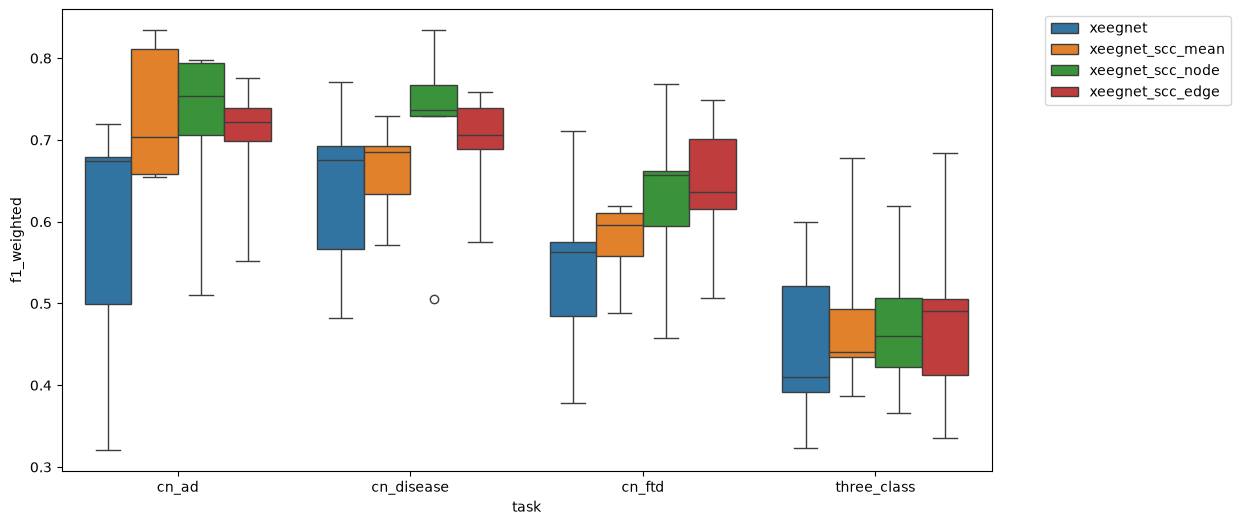

In [124]:


# create a boxplot of the f1_weighted scores for each model_kind and reducer_mode_scc, for the test datasplit
import seaborn as sns 
import matplotlib.pyplot as plt

# set figure size
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=filter_results_dataframe(df_result_window, datasplit="test"),
    # y="f1_macro",
    # y="f1_macro",
    y="f1_weighted",
    hue="model_kind_reducer",
    x="task",
    whis=5.0,  # default is 1.5; higher = wider whiskers = fewer outlier points
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:
sns.boxplot(
    data=filter_results_dataframe(df_results, datasplit="test"),
    # y="f1_macro",
    # y="f1_macro",
    y="f1_weighted",
    hue="model_kind_reducer",
    x="task",
    whis=5.0,  # default is 1.5; higher = wider whiskers = fewer outlier points
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

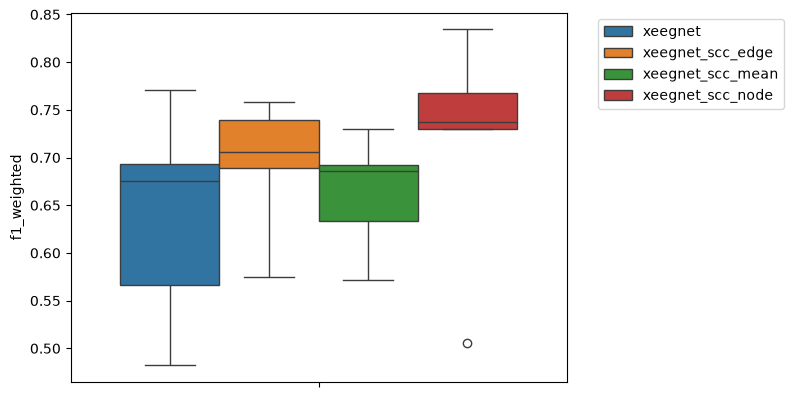

In [ ]:


# create a boxplot of the f1_weighted scores for each model_kind and reducer_mode_scc, for the test datasplit
import seaborn as sns 

sns.boxplot(
    data=df_results[df_results["datasplit"] == "test"],
    # y="f1_macro",
    # y="f1_macro",
    y="f1_weighted",
    hue="model_kind_reducer",
    whis=4.0,  # default is 1.5; higher = wider whiskers = fewer outlier points
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

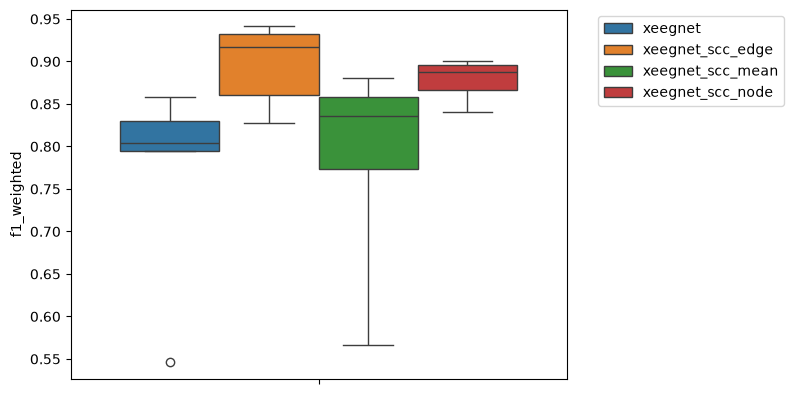

In [ ]:
sns.boxplot(
    data=df_results[df_results["datasplit"] == "train"],
    # y="f1_macro",
    # y="f1_macro",
    y="f1_weighted",
    hue="model_kind_reducer",
    whis=4.0,  # default is 1.5; higher = wider whiskers = fewer outlier points
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

### subject level analysis

2

In [338]:
task = "cn_disease"  # Alzheimer's disease vs. control

print(f"Running task: {task}")
print(f"classes = {nb_classes}")

Running task: cn_disease
classes = 2


In [ ]:
# # model_versions = [200]
# # model_versions = [200, 201, 202, 203, 204]
# model_versions = [200, 201]
# # model_versions = [200, 201]
# model_kinds = ["xeegnet_scc", "xeegnet"] #, "xeegnet"
# # model_kinds = ["xeegnet_scc"] #, "xeegnet"
# # reducer_mode_scc_list = ["mean", "node", "edge"]
# reducer_mode_scc_list = ["node", "mean"]
# # eval_datasplits = ["test"]
# # results_name = "xeegnet_scc_model_versions_200_204_metrics.csv"

# eval_datasplits = ["test", "val", "train"] #, "val", "train"
# results_name = "xeegnet_scc_model_versions_200_204_metrics_v2.csv"

model_kind_list = ["xeegnet_scc", "xeegnet"]

saved_model_runs = []

for model_version in model_versions:
    for model_kind in model_kind_list:
        modes = reducer_mode_scc_list if model_kind == "xeegnet_scc" else [None]
        for reducer_mode_scc in modes:
            model_prefix = MODEL_PREFIXES_BIB[model_kind]

            model_name = generate_model_name(model_kind, model_version, n_max=None, reducer_mode_scc=reducer_mode_scc)
            model_path = generate_model_path(PRETRAINED_MODEL_DIR, task, model_name)
           
            saved_model_runs.append(
                {
                    "model_kind": model_kind,
                    "model_path": model_path,
                    # "model_path": PRETRAINED_MODEL_DIR / "pretrained_models_local_backup"  /  f"{model_prefix}_v{model_version}.pt",
                    "reducer_mode_scc": reducer_mode_scc,
                }
            )

saved_model_results = []
for run in saved_model_runs:
    saved_model_results.extend(evaluate_saved_model(run["model_path"], 
                                                    run["model_kind"], 
                                                    reducer_mode_scc=run["reducer_mode_scc"], 
                                                    data_x_y_scc_id=data_x_y_scc_id_taskadapted,
                                                    nb_classes=nb_classes
                                                    ),)

df_results = (
    pd.DataFrame(saved_model_results)
    .sort_values(["model_version", "model_kind", "reducer_mode_scc", "datasplit"])
    .reset_index(drop=True)
)

saved_model_results_name = PRETRAINED_MODEL_DIR / results_name

# saved_model_results_df.to_csv(saved_model_results_name, index=False)
# saved_model_results_df


-- Evaluating xeegnet_scc v200 (reducer=node) at /home/mgrabner/eeglass2/all-in-on-eeg/backend/ml/pretrained_models/cn_disease/xeegnet_scc_model_reducermode_node_v200.pt --
-- Evaluating xeegnet_scc v200 (reducer=mean) at /home/mgrabner/eeglass2/all-in-on-eeg/backend/ml/pretrained_models/cn_disease/xeegnet_scc_model_v200.pt --
-- Evaluating xeegnet_scc v200 (reducer=edge) at /home/mgrabner/eeglass2/all-in-on-eeg/backend/ml/pretrained_models/cn_disease/xeegnet_scc_model_reducermode_edge_v200.pt --
-- Evaluating xeegnet v200 (reducer=None) at /home/mgrabner/eeglass2/all-in-on-eeg/backend/ml/pretrained_models/cn_disease/xeegnet_model_v200.pt --
-- Evaluating xeegnet_scc v201 (reducer=node) at /home/mgrabner/eeglass2/all-in-on-eeg/backend/ml/pretrained_models/cn_disease/xeegnet_scc_model_reducermode_node_v201.pt --
-- Evaluating xeegnet_scc v201 (reducer=mean) at /home/mgrabner/eeglass2/all-in-on-eeg/backend/ml/pretrained_models/cn_disease/xeegnet_scc_model_v201.pt --
-- Evaluating xeegnet

In [ ]:
df_results

,model_version,model_kind,reducer_mode_scc,model_name,model_path,train_epochs,datasplit,aggregation,n_samples,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,precision_weighted,recall_macro,recall_weighted
0,200,xeegnet,NaN,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,test,window,3604,0.784684,0.711336,0.727584,0.770357,0.777492,0.781799,0.711336,0.784684
1,200,xeegnet,NaN,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,test,subject_majority,18,0.888889,0.833333,0.861538,0.882051,0.928571,0.904762,0.833333,0.888889
2,200,xeegnet,NaN,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,train,window,10981,0.860395,0.826952,0.836606,0.858039,0.849835,0.858492,0.826952,0.860395
3,200,xeegnet,NaN,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,train,subject_majority,55,0.909091,0.885449,0.891775,0.908304,0.899038,0.908217,0.885449,0.909091
4,200,xeegnet,NaN,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,val,window,3274,0.745877,0.703400,0.711372,0.736306,0.736917,0.741985,0.703400,0.745877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,204,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v204.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,test,subject_majority,18,0.722222,0.666667,0.672727,0.715152,0.684615,0.712821,0.666667,0.722222
116,204,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v204.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,train,window,10899,0.900725,0.880430,0.884665,0.900148,0.889373,0.899938,0.880430,0.900725
117,204,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v204.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,train,subject_majority,54,0.981481,0.986486,0.978865,0.981619,0.972222,0.982510,0.986486,0.981481
118,204,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v204.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,val,window,3611,0.756854,0.731769,0.733689,0.755766,0.735954,0.754980,0.731769,0.756854


In [ ]:
df_results[df_results["aggregation"]=="subject_majority"].groupby(["datasplit", "model_kind", "reducer_mode_scc"], dropna=False)["accuracy"].mean()

datasplit  model_kind   reducer_mode_scc
test       xeegnet      NaN                 0.722222
           xeegnet_scc  edge                0.744444
                        mean                0.688889
                        node                0.755556
train      xeegnet      NaN                 0.828969
           xeegnet_scc  edge                0.950427
                        mean                0.839593
                        node                0.931121
val        xeegnet      NaN                 0.822222
           xeegnet_scc  edge                0.800000
                        mean                0.800000
                        node                0.900000
Name: accuracy, dtype: float64

In [ ]:
df_results[df_results["aggregation"]=="window"].groupby(["datasplit", "model_kind", "reducer_mode_scc"], dropna=False)["f1_weighted"].mean()

datasplit  model_kind   reducer_mode_scc
test       xeegnet      NaN                 0.637567
           xeegnet_scc  edge                0.693594
                        mean                0.662553
                        node                0.714878
train      xeegnet      NaN                 0.766785
           xeegnet_scc  edge                0.895878
                        mean                0.782979
                        node                0.878005
val        xeegnet      NaN                 0.715666
           xeegnet_scc  edge                0.708474
                        mean                0.701771
                        node                0.715758
Name: f1_weighted, dtype: float64

In [93]:
saved_model_results_name

PosixPath('/home/mgrabner/eeglass2/all-in-on-eeg/backend/ml/pretrained_models/cn_disease_xeegnet_scc_reducer_modes_model_versions_200_204_metrics.csv')


## results three cases

In [ ]:
# fill the nan values in the reducer_mode_scc column with "" for xeegnet models
df_results["reducer_mode_scc"] = df_results.apply(
    lambda row: "" if row["model_kind"] == "xeegnet" and pd.isna(row["reducer_mode_scc"]) else row["reducer_mode_scc"],
    axis=1
)

df_results
df_results[df_results["datasplit"] == "test"]

,model_version,model_kind,reducer_mode_scc,model_name,model_path,train_epochs,datasplit,n_samples,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,precision_weighted,recall_macro,recall_weighted
0,200,xeegnet,,xeegnet_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,test,3604,0.466704,0.444765,0.390797,0.409623,0.365534,0.380042,0.444765,0.466704
3,200,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,test,3604,0.420921,0.410526,0.402336,0.412662,0.400255,0.410251,0.410526,0.420921
6,200,xeegnet_scc,mean,xeegnet_scc_model_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,test,3604,0.466981,0.444402,0.418096,0.434645,0.414655,0.424914,0.444402,0.466981
9,200,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v200.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,test,3604,0.437014,0.431970,0.416282,0.422800,0.417883,0.425936,0.431970,0.437014
12,201,xeegnet,,xeegnet_model_v201.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,test,3622,0.545003,0.531723,0.513748,0.521945,0.539114,0.539611,0.531723,0.545003
15,201,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v201.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,test,3622,0.522639,0.511017,0.497644,0.505535,0.506420,0.509356,0.511017,0.522639
18,201,xeegnet_scc,mean,xeegnet_scc_model_v201.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,test,3622,0.692711,0.679914,0.671470,0.677734,0.714489,0.710720,0.679914,0.692711
21,201,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v201.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,test,3622,0.518498,0.511384,0.502590,0.506972,0.518528,0.520399,0.511384,0.518498
24,202,xeegnet,,xeegnet_model_v202.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,test,3416,0.332260,0.323929,0.318835,0.323042,0.367365,0.363454,0.323929,0.332260
27,202,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v202.pt,/home/mgrabner/eeglass2/all-in-on-eeg/backend/...,None,test,3416,0.332845,0.336271,0.336458,0.335445,0.359613,0.360375,0.336271,0.332845


In [ ]:
df_results["model_kind_reducer"] = df_results.apply(
    lambda row: f"{row['model_kind']}_{row['reducer_mode_scc']}" if row['model_kind'] == 'xeegnet_scc' else row['model_kind'],
    axis=1
)

# create a boxplot of the f1_weighted scores for each model_kind and reducer_mode_scc, for the test datasplit
import seaborn as sns 

sns.boxplot(
    data=df_results[df_results["datasplit"] == "test"],
    # y="f1_macro",
    # y="f1_macro",
    y="f1_weighted",
    hue="model_kind_reducer",
    whis=4.0,  # default is 1.5; higher = wider whiskers = fewer outlier points
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

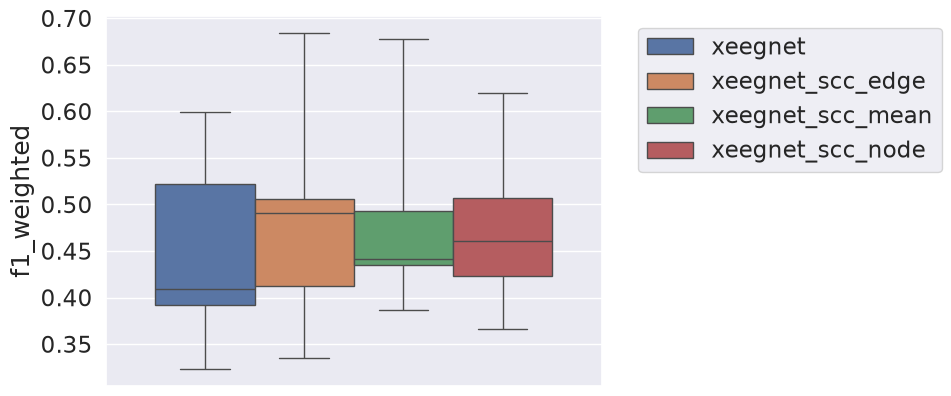

In [ ]:
# create a boxplot of the f1_weighted scores for each model_kind and reducer_mode_scc, for the test datasplit
import seaborn as sns 

sns.boxplot(
    data=df_results[df_results["datasplit"] == "test"],
    # y="f1_macro",
    # y="f1_macro",
    y="f1_weighted",
    hue="model_kind_reducer",
    whis=4.0,  # default is 1.5; higher = wider whiskers = fewer outlier points
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

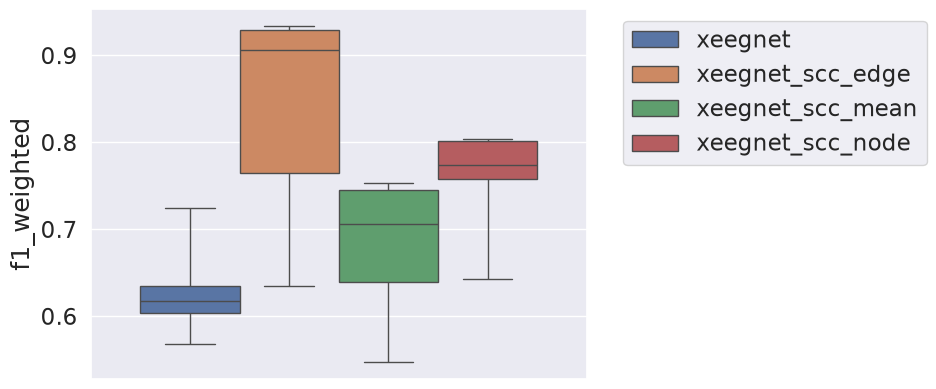

In [ ]:
sns.boxplot(
    data=df_results[df_results["datasplit"] == "train"],
    y="f1_weighted",
    hue="model_kind_reducer",
    whis=3.0,  # default is 1.5; higher = wider whiskers = fewer outlier points
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:
df_results.groupby(["datasplit", "model_kind", "reducer_mode_scc"], dropna=False)["f1_weighted"].mean()

datasplit  model_kind   reducer_mode_scc
test       xeegnet      N/A                 0.449106
           xeegnet_scc  edge                0.485588
                        mean                0.486752
                        node                0.475159
train      xeegnet      N/A                 0.629644
           xeegnet_scc  edge                0.833840
                        mean                0.678018
                        node                0.755894
val        xeegnet      N/A                 0.445479
           xeegnet_scc  edge                0.525845
                        mean                0.452286
                        node                0.487043
Name: f1_weighted, dtype: float64

In [ ]:
df_results.groupby(["datasplit", "model_kind", "reducer_mode_scc"], dropna=False)["f1_macro"].mean()

datasplit  model_kind   reducer_mode_scc
test       xeegnet      N/A                 0.435662
           xeegnet_scc  edge                0.480607
                        mean                0.472122
                        node                0.464770
train      xeegnet      N/A                 0.577812
           xeegnet_scc  edge                0.817979
                        mean                0.631634
                        node                0.729605
val        xeegnet      N/A                 0.433042
           xeegnet_scc  edge                0.519874
                        mean                0.437451
                        node                0.477148
Name: f1_macro, dtype: float64


model_seed 42 for edge, mean; node model_seed 7
accuracy
datasplit  model_kind   reducer_mode_scc
test       xeegnet      NaN                 0.488374
           xeegnet_scc  edge                0.488655
                        mean                0.529838
                        node                0.477979
train      xeegnet      NaN                 0.653865
           xeegnet_scc  edge                0.827716
                        mean                0.698453
                        node                0.725221
val        xeegnet      NaN                 0.482422
           xeegnet_scc  edge                0.526993
                        mean                0.492685
                        node                0.497403
Name: accuracy, dtype: float64


f1 weighted:
datasplit  model_kind   reducer_mode_scc
test       xeegnet      NaN                 0.449106
           xeegnet_scc  edge                0.485588
                        mean                0.486752
                        node                0.447197
train      xeegnet      NaN                 0.629644
           xeegnet_scc  edge                0.833840
                        mean                0.678018
                        node                0.711565
val        xeegnet      NaN                 0.445479
           xeegnet_scc  edge                0.525845
                        mean                0.452286
                        node                0.471759
Name: f1_weighted, dtype: float64





model_seed 42 for edge, mean; node model_seed 42 or 52
datasplit  model_kind   reducer_mode_scc
test       xeegnet      NaN                 0.488374
           xeegnet_scc  edge                0.488655
                        mean                0.529838
                        node                0.468385
train      xeegnet      NaN                 0.653865
           xeegnet_scc  edge                0.827716
                        mean                0.698453
                        node                0.674266
val        xeegnet      NaN                 0.482422
           xeegnet_scc  edge                0.526993
                        mean                0.492685
                        node                0.493969
Name: accuracy, dtype: float64




datasplit  model_kind   reducer_mode_scc
test       xeegnet      NaN                 0.449106
           xeegnet_scc  edge                0.485588
                        mean                0.486752
                        node                0.447197
Name: f1_weighted, dtype: float64









In [ ]:
df_results[df_results["datasplit"] == "test"].groupby(["datasplit", "model_kind", "reducer_mode_scc"], dropna=False)["f1_weighted"].mean()

datasplit  model_kind   reducer_mode_scc
test       xeegnet      NaN                 0.449106
           xeegnet_scc  edge                0.485588
                        mean                0.486752
                        node                0.439656
Name: f1_weighted, dtype: float64

In [ ]:
df_results[df_results["datasplit"] == "test"]

,model_version,model_kind,reducer_mode_scc,model_name,model_path,train_epochs,datasplit,n_samples,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,precision_weighted,recall_macro,recall_weighted
0,200,xeegnet,NaN,xeegnet_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.466704,0.444765,0.390797,0.409623,0.365534,0.380042,0.444765,0.466704
3,200,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.420921,0.410526,0.402336,0.412662,0.400255,0.410251,0.410526,0.420921
6,200,xeegnet_scc,mean,xeegnet_scc_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.466981,0.444402,0.418096,0.434645,0.414655,0.424914,0.444402,0.466981
9,200,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.428690,0.418072,0.422441,0.432008,0.428856,0.437427,0.418072,0.428690
12,201,xeegnet,NaN,xeegnet_model_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.545003,0.531723,0.513748,0.521945,0.539114,0.539611,0.531723,0.545003
15,201,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.522639,0.511017,0.497644,0.505535,0.506420,0.509356,0.511017,0.522639
18,201,xeegnet_scc,mean,xeegnet_scc_model_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.692711,0.679914,0.671470,0.677734,0.714489,0.710720,0.679914,0.692711
21,201,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.518498,0.499231,0.453978,0.468847,0.464182,0.471907,0.499231,0.518498
24,202,xeegnet,NaN,xeegnet_model_v202.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3416,0.332260,0.323929,0.318835,0.323042,0.367365,0.363454,0.323929,0.332260
27,202,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v202.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3416,0.332845,0.336271,0.336458,0.335445,0.359613,0.360375,0.336271,0.332845


In [ ]:
df_results.groupby(["datasplit", "model_kind"])["accuracy"].mean()

datasplit  model_kind 
test       xeegnet        0.505853
           xeegnet_scc    0.450363
Name: accuracy, dtype: float64

In [ ]:
df_results

,model_version,model_kind,reducer_mode_scc,model_name,model_path,train_epochs,datasplit,n_samples,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,precision_weighted,recall_macro,recall_weighted
0,200,xeegnet,NaN,xeegnet_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.466704,0.444765,0.390797,0.409623,0.365534,0.380042,0.444765,0.466704
1,200,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.485017,0.477685,0.458536,0.466049,0.467785,0.474303,0.477685,0.485017
2,200,xeegnet_scc,mean,xeegnet_scc_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.367647,0.363878,0.291742,0.297456,0.348222,0.348129,0.363878,0.367647
3,200,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.496670,0.479802,0.470237,0.484119,0.465647,0.476464,0.479802,0.496670
4,201,xeegnet,NaN,xeegnet_model_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.545003,0.531723,0.513748,0.521945,0.539114,0.539611,0.531723,0.545003
5,201,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.481226,0.470417,0.454506,0.461816,0.462276,0.465115,0.470417,0.481226
6,201,xeegnet_scc,mean,xeegnet_scc_model_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.338763,0.338380,0.336971,0.339239,0.355290,0.359844,0.338380,0.338763
7,201,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.532855,0.519860,0.505260,0.514569,0.515293,0.520105,0.519860,0.532855


## train & evaluate single models


In [70]:
# model = shallow_net
# model_curr = xeegnet
model_curr = build_xeegnet_scc(nb_classes=nb_classes, Chans=Chans, Samples=sample_length, Fs=srate)


In [71]:
optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
gamma = 0.995
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

# factor = 0.5
# patience_scheduler = 10
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=factor, patience=patience_scheduler)

# Define selfEEG's EarlyStopper with large patience to act as a model checkpoint
earlystop = selfeeg.ssl.EarlyStopping(
    patience=15, min_delta=1e-04, record_best_weights=True
)

validation_loss_args = []
if taskToEval.casefold() == "alzheimer" or ("cognitive" in taskToEval.casefold()):
    lossFnc = lossMulti
else:
    lossFnc = lossBinary

In [72]:
# def load_participant_splits(split_path=None) -> dict[str, dict[str, list[int]]]:
#     if split_path is None:
#         split_path = Path("backend") / "ml" / "data_splits.json"
#     with split_path.open("r", encoding="utf-8") as file:
#         return json.load(file)

In [73]:
model_version = 200

n_max = 1500
n_max = None

parameters = PARAMETERS_DEFAULT
training_parameters = TRAINING_PARAMETERS_DEFAULT
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")


In [74]:
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")
split_index = model_version - 200

if isinstance(model_curr, xEEGNetSCC):
    model_type = f"xeegnet_scc_model"
elif isinstance(model_curr, selfeeg.models.xEEGNet):
    model_type = f"xeegnet_model"
elif isinstance(model_curr, ShallowNet):
    model_type = f"shallownet_model"


if not n_max:
    modelname = f"{model_type}_v{model_version}.pt"
    model_path = PRETRAINED_MODEL_DIR / modelname
else:
    modelname = f"{model_type}_v{model_version}_nmax{n_max}.pt"
    model_path = PRETRAINED_MODEL_DIR / modelname

print(f"Model name: {modelname}")
print(f"Model path: {model_path}")

split_path = Path(dir_base) / "backend" / "ml" / "data_splits.json"

participants_split = load_participant_splits(split_path=split_path)[str(split_index)]

df_metadata = load_metadata(dir_data=dir_data)
df_metadata["datasplit"] = "test"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["train"]), "datasplit"] = "train"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["val"]), "datasplit"] = "val"

participant_ids_train = participants_split["train"]
participant_ids_val = participants_split["val"]
participant_ids_test = participants_split["test"]

participant_ids_train_str = [gen_participant_id_long(pid) for pid in participant_ids_train]
participant_ids_val_str = [gen_participant_id_long(pid) for pid in participant_ids_val]
participant_ids_test_str = [gen_participant_id_long(pid) for pid in participant_ids_test]


Model name: xeegnet_scc_model_v200.pt
Model path: C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_v200.pt


In [75]:
# df_metadata, trainloader, valloader, testloader, xy = get_train_val_test_loader(
#     dir_data=dir_data,
#     df_metadata=df_metadata,
#     participant_ids_train=participants_split["train"],
#     participant_ids_val=participants_split["val"],
#     n_max=n_max
# )


# x_train, y_train, x_val, y_val, x_test, y_test = xy

In [76]:
# n_max

In [93]:
# check if model curr is scc

if isinstance(model_curr, xEEGNetSCC):
    print("model_curr is xEEGNetSCC; using cached SCC for dataloaders.")

    store  = SCCStore(
        root=Path(dir_data_outer) / "scc_cache" 
    )
    scc_params = SCCParams.default(sfreq=srate, sample_length=sample_length)

    trainloader, valloader, testloader, xy_subjects = get_dataloaders_xysubjectids(
    dir_data=dir_data,
    participant_ids_train=participant_ids_train,
    participant_ids_val=participant_ids_val,
    participant_ids_test=participant_ids_test,
    df_metadata=df_metadata,
    parameters=PARAMETERS_DEFAULT,
    n_max=n_max,
    use_cached_scc=True,
    store=store,
    scc_params=scc_params,
    dataset_id="ds004504",
    n_channels=Chans,
    source="derivatives",
    load_model_windows_for_participant=load_model_windows_for_participant,
)
else:
    trainloader, valloader, testloader, xy_subjects = get_dataloaders_xysubjectids(
        dir_data=dir_data,
        participant_ids_train=participant_ids_train,
        participant_ids_val=participant_ids_val,
        df_metadata=df_metadata,
        parameters=parameters,
        use_cached_scc=False,
        n_max=n_max,
    )

x_train, y_train, subject_ids_train, scc_train, x_val, y_val, subject_ids_val, scc_val, x_test, y_test, subject_ids_test, scc_test = xy_subjects

model_curr is xEEGNetSCC; using cached SCC for dataloaders.
Loaded derivative model windows: x shape (17859, 19, 500), y shape (17859,)
Loaded x (17859, 19, 500), scc (17859, 7, 171), y (17859,)


In [106]:
y_train

array([1, 1, 1, ..., 2, 2, 2], shape=(10981,))

In [108]:
y_train2

tensor([1, 1, 1,  ..., 0, 1, 1])

In [107]:
x_train2, y_train2 = get_x_y_from_loader(trainloader)

In [105]:
x_train

array([[[-44.810177  , -22.623198  , -12.431333  , ..., -10.761807  ,
          -8.434462  ,  -9.3336935 ],
        [-33.61159   , -16.673063  ,  -9.607849  , ..., -10.045416  ,
         -14.116623  , -13.487215  ],
        [ -9.109775  , -11.893477  , -15.592975  , ..., -24.2273    ,
         -31.043865  , -25.79072   ],
        ...,
        [-19.907846  , -13.372591  , -10.843512  , ..., -18.564726  ,
         -26.369976  , -23.199934  ],
        [-18.832417  , -13.146844  ,  -9.481776  , ..., -22.5467    ,
         -27.468716  , -24.69808   ],
        [-19.1118    , -12.684691  , -10.466578  , ..., -23.84007   ,
         -25.879204  , -19.75081   ]],

       [[-18.153572  , -25.151808  , -17.961424  , ..., -23.688705  ,
         -33.578606  , -29.502907  ],
        [-17.47351   , -24.608889  , -21.282913  , ..., -24.677813  ,
         -31.625275  , -30.083612  ],
        [-21.14333   , -30.513397  , -40.208694  , ..., -20.89838   ,
         -28.119602  , -29.32825   ],
        ...,


In [87]:
def get_x_y_from_loader(loader):
    x_batches = []
    y_batches = []

    for inputs, targets in loader:
        if isinstance(inputs, (list, tuple)):
            x_batch = inputs[0]
        else:
            x_batch = inputs

        x_batches.append(x_batch.cpu())
        y_batches.append(targets.cpu())

    x = torch.cat(x_batches, dim=0)
    y = torch.cat(y_batches, dim=0)
    return x,y


In [ ]:
# get x_train from trainloader
x_train

NameError: name 'trainloader' is not defined

In [ ]:
loss_summary = train_model(
    model=model_curr,
    train_dataloader=trainloader,
    epochs=100,
    optimizer=optimizer,
    loss_func=lossFnc,
    lr_scheduler=scheduler,
    EarlyStopper=earlystop,
    validation_dataloader=valloader,
    # validation_loss_func=lossVal,
    validation_loss_args=validation_loss_args,
    verbose=verbose,
    device=device,
    return_loss_info=True,
)

save_model(model_curr, model_path)

epoch [1/100]
   val 52/52: 100%|███████████████| 224/224 [57.80 Batch/s, train_loss=2.57971, val_loss=2.35622]  
epoch [2/100]
   val 52/52: 100%|███████████████| 224/224 [58.46 Batch/s, train_loss=2.21775, val_loss=1.95927]  
epoch [3/100]
   val 52/52: 100%|███████████████| 224/224 [59.36 Batch/s, train_loss=1.93654, val_loss=1.67259]  
epoch [4/100]
   val 52/52: 100%|███████████████| 224/224 [59.67 Batch/s, train_loss=1.73289, val_loss=1.56308]  
epoch [5/100]
   val 52/52: 100%|███████████████| 224/224 [59.23 Batch/s, train_loss=1.59760, val_loss=1.44505]  
epoch [6/100]
   val 52/52: 100%|███████████████| 224/224 [60.58 Batch/s, train_loss=1.48459, val_loss=1.34726]  
epoch [7/100]
   val 52/52: 100%|███████████████| 224/224 [60.06 Batch/s, train_loss=1.39905, val_loss=1.29317]  
epoch [8/100]
   val 52/52: 100%|███████████████| 224/224 [58.36 Batch/s, train_loss=1.32774, val_loss=1.25080]  
epoch [9/100]
   val 52/52: 100%|███████████████| 224/224 [59.46 Batch/s, train_loss=1.2

## Evaluate model


In [64]:
def get_performances_metrics(y_true, y_pred):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
    }
    return metrics

In [160]:
from backend.ml.model import build_xeegnet

In [65]:
# model = model_curr

In [166]:
print(f"model version {model_version} ")
print(f"n_max: {n_max} ")

reload = True

n_max = None

# model_type = "xeegnet_scc"
model_type = "xeegnet"

if n_max:
    model_name = f"{model_type}_model_v{model_version}_nmax{n_max}.pt"
else:
    model_name = f"{model_type}_model_v{model_version}.pt"

model_path = PRETRAINED_MODEL_DIR / model_name
print(f"model path: {model_path}")

if reload:
    print(f"Reloading model from {model_path}...")
    if model_type == "xeegnet":
        model = build_xeegnet()

    elif model_type == "xeegnet_scc":
        model = build_xeegnet_scc()

    model = load_model_weights(model_path, model=model, device=device)

else:
    model = model_curr


model version 200 
n_max: None 
model path: C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt
Reloading model from C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt...
Loading model from C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_curr = model_curr.to(device)
model_curr = model

# cast from torch.cuda.FloatTensor to torch.FloatTensor
# x_train_eeg = torch.Tensor(x_train)
# x_train = x_train.to(device)

if isinstance(model_curr, xEEGNetSCC):
    print("Evaluating xEEGNetSCC with cached SCC inputs.")
    eval_store = store
    eval_params = scc_params
    eval_df = load_metadata(dir_data)
    eval_label_of = {f"sub-{int(r.participant_id.split('-')[1]):03d}": int(r.group_encoded) for r in eval_df.itertuples()}

    def eval_split(participant_ids: list[int], split_name: str):
        x_eval, y_eval, scc_eval, _ = build_x_y_scc(
            dir_data,
            participant_ids,
            eval_label_of,
            eval_store,
            eval_params,
            load_model_windows_for_participant,
            dataset_id="ds004504",
            n_channels=Chans,
            source="derivatives",
            sample_length=sample_length,
        )
        x_eval_t = torch.as_tensor(x_eval, dtype=torch.float32, device=device)
        scc_eval_t = torch.as_tensor(scc_eval, dtype=torch.float32, device=device)
        with torch.no_grad():
            y_out = model_curr([x_eval_t, scc_eval_t])
        y_pred = torch.argmax(y_out, dim=1).detach().cpu().numpy()
        metrics = get_performances_metrics(y_eval, y_pred)
        print(f"Evaluating on {split_name} set:")
        print(metrics)
        print("\n") 

    eval_split(participant_ids_train, "train")
    eval_split(participant_ids_val, "val")
    eval_split(participant_ids_test, "test")
else:
    for dataset_type, x_data, y_data in zip(
        ["train", "val", "test"], [x_train, x_val, x_test], [y_train, y_val, y_test]
    ):
        print(f"Evaluating on {dataset_type} set:")
        x_data = torch.Tensor(x_data)
        x_data = x_data.to(device)
        with torch.no_grad():
            y_out = model_curr(x_data)
        y_pred = torch.argmax(y_out, dim=1).detach().cpu().numpy()
        metrics = get_performances_metrics(y_data, y_pred)
        print(metrics)
        print("\n")

Evaluating on train set:
{'accuracy': 0.7423731900555505, 'f1_macro': 0.6930250193508659, 'precision_macro': 0.7544014161026631, 'recall_macro': 0.6919962821579189}


Evaluating on val set:
{'accuracy': 0.5436774587660355, 'f1_macro': 0.48000562396124496, 'precision_macro': 0.5094921488241387, 'recall_macro': 0.5208795765692115}


Evaluating on test set:
{'accuracy': 0.5300252844500632, 'f1_macro': 0.42312599895775227, 'precision_macro': 0.4136975828519291, 'recall_macro': 0.4483254483135887}




           |-----------------------------------------|
           |                SCORE SUMMARY            |
           |-----------------------------------------|
           |  Accuracy score:                 0.530  |
           |  Accuracy score weighted:        0.448  |
           |-----------------------------------------|
           |  Precision score micro:          0.530  |
           |  Precision score macro:          0.414  |
           |  Precision score weighted:       0.485  |
           |-----------------------------------------|
           |  Recall score micro:             0.530  |
           |  Recall score macro:             0.448  |
           |  Recall score weighted:          0.530  |
           |-----------------------------------------|
           |  F1-score micro:                 0.530  |
           |  F1-score macro:                 0.423  |
           |  F1-score weighted:              0.500  |
           |-----------------------------------------|
          

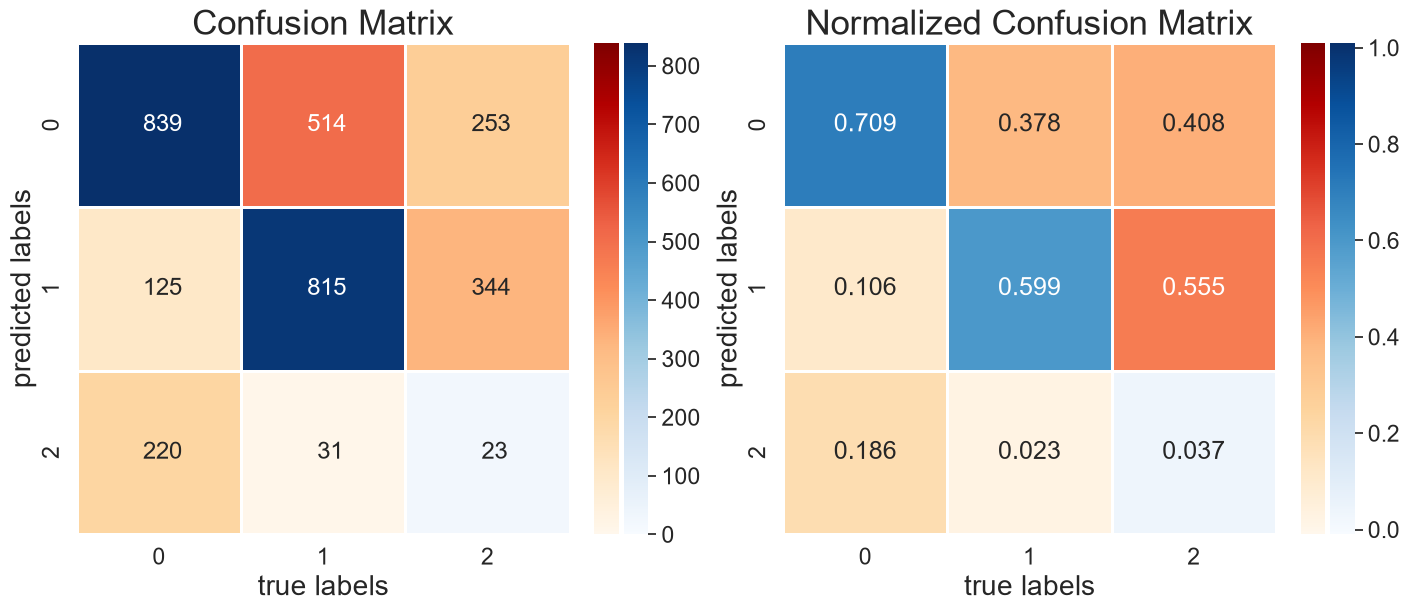

Balanced Accuracy:  44.83 %


In [ ]:
classlabels = y_test

# testloader_scc = 

if isinstance(model_curr, xEEGNetSCC):
    scores = get_performances(
        loader2eval=testloader_scc,
        Model=model_curr,
        device=device,
        nb_classes=nb_classes,
        return_scores=True,
        verbose=verbose,
        plot_confusion=True,
        class_labels=classlabels,
    )
else:
    scores = get_performances(
        loader2eval=testloader,
        Model=model_curr,
        device=device,
        nb_classes=nb_classes,
        return_scores=True,
        verbose=verbose,
        plot_confusion=True,
        class_labels=classlabels,
    )
print(f"Balanced Accuracy: {scores['accuracy_weighted'] * 100: .2f} %")

#### shallow net 2


In [ ]:
if False:
    loss_summary = train_model(
        model=shallow_net_2,
        train_dataloader=trainloader,
        epochs=30,
        optimizer=optimizer,
        loss_func=lossFnc,
        lr_scheduler=scheduler,
        EarlyStopper=earlystop,
        validation_dataloader=valloader,
        validation_loss_func=lossVal,
        validation_loss_args=validation_loss_args,
        verbose=verbose,
        device=device,
        return_loss_info=True,
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    shallow_net = shallow_net.to(device)

    # cast from torch.cuda.FloatTensor to torch.FloatTensor
    # x_train_eeg = torch.Tensor(x_train)
    x_train = x_train.to(device)
    y_train_out = shallow_net(x_train)
    y_train_pred = torch.argmax(y_train_out, dim=1).detach().cpu().numpy()

    print("ShallowNet 2 performance on training set:")
    get_performances_metrics(y_train, y_train_pred)

## Scores


           |-----------------------------------------|
           |                SCORE SUMMARY            |
           |-----------------------------------------|
           |  Accuracy score:                 0.167  |
           |  Accuracy score weighted:        0.167  |
           |-----------------------------------------|
           |  Precision score micro:          0.167  |
           |  Precision score macro:          0.083  |
           |  Precision score weighted:       0.083  |
           |-----------------------------------------|
           |  Recall score micro:             0.167  |
           |  Recall score macro:             0.167  |
           |  Recall score weighted:          0.167  |
           |-----------------------------------------|
           |  F1-score micro:                 0.167  |
           |  F1-score macro:                 0.111  |
           |  F1-score weighted:              0.111  |
           |-----------------------------------------|
          

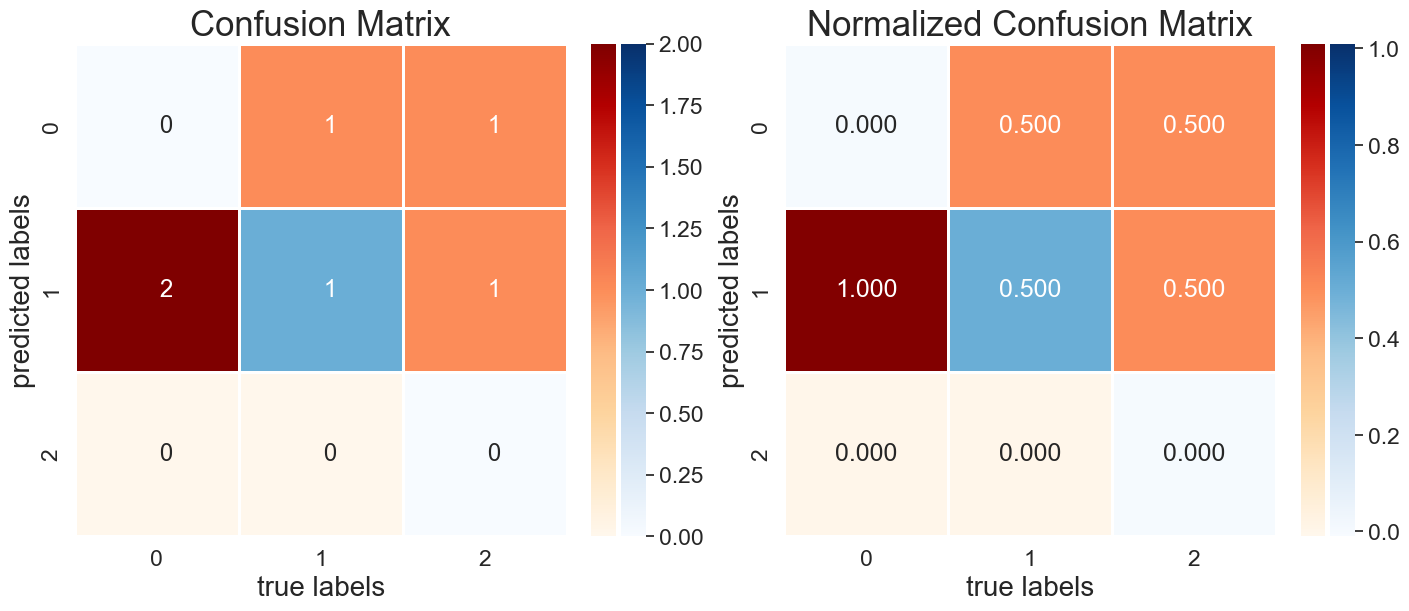

Balanced Accuracy:  16.67 %


In [ ]:
classlabels = y_test

scores = get_performances(
    loader2eval=testloader,
    Model=model_curr,
    device=device,
    nb_classes=nb_classes,
    return_scores=True,
    verbose=verbose,
    plot_confusion=True,
    class_labels=classlabels,
)
print(f"Balanced Accuracy: {scores['accuracy_weighted'] * 100: .2f} %")

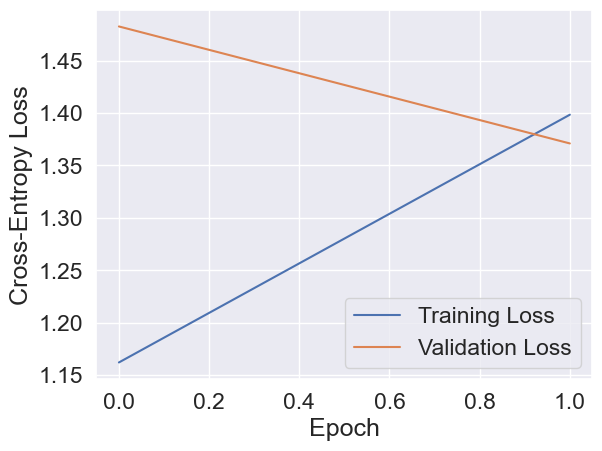

In [178]:
training_loss_curve = []
validation_loss_curve = []
# Iterate through the dictionary, filtering out entries with None values
for key, (train_loss, val_loss) in loss_summary.items():
    if train_loss is not None and val_loss is not None:
        training_loss_curve.append(train_loss)
        validation_loss_curve.append(val_loss)

scores["training_loss_curve"] = training_loss_curve
scores["validation_loss_curve"] = validation_loss_curve

plt.plot(training_loss_curve, label="Training Loss")
plt.plot(validation_loss_curve, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.show()

## Save the model


In [179]:
model_name = "xeeg_test_mini.pt"

dir_models = os.path.join(dir_shallownetXAI, "newmodels") + sep
model_path = os.path.join(dir_models, model_name)

dirResults = os.path.join(dir_shallownetXAI, "new_results") + sep
results_path = os.path.join(dirResults, f"{model_name[:-3]}_results.pickle")

In [180]:
results_path

'..\\..\\backend\\experiments_xeegnet\\shallownetXAI_main\\new_results\\xeeg_test_mini_results.pickle'

In [ ]:
print("model dir:", dir_models, os.path.isdir(dir_models))
print("model path:", model_path, os.path.abspath(model_path))
print("results dir:", dirResults, os.path.isdir(dirResults))
print(
    "results path:",
    results_path,
    os.path.abspath(results_path),
    os.path.exists(results_path),
)

model dir: ..\..\backend\experiments_xeegnet\shallownetXAI_main\newmodels\ True
model path: ..\..\backend\experiments_xeegnet\shallownetXAI_main\newmodels\xeeg_test_mini.pt c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\experiments_xeegnet\shallownetXAI_main\newmodels\xeeg_test_mini.pt
results dir: ..\..\backend\experiments_xeegnet\shallownetXAI_main\new_results\ True
results path: ..\..\backend\experiments_xeegnet\shallownetXAI_main\new_results\xeeg_test_mini_results.pickle c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\experiments_xeegnet\shallownetXAI_main\new_results\xeeg_test_mini_results.pickle True


In [183]:
save_model = False

if save_model:
    # Save the model
    model_curr.eval()
    model_curr.to(device="cpu")
    torch.save(model_curr.state_dict(), model_path)

    # Save the scores
    with open(results_path, "wb") as handle:
        pickle.dump(scores, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Compare training&inference times


In [ ]:
from time import time

In [ ]:
def inference(model, x: torch.Tensor | np.ndarray):
    model.eval()

    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x).float()
    with torch.no_grad():
        out = model(x)
    return out

In [ ]:
n_batches = 100
x = torch.randn(n_batches, Chans, sample_length, dtype=torch.float32)
cached_scc = torch.randn(n_batches, len(BANDS), Chans*(Chans-1)//2, dtype=torch.float32)

# xeegnet
current_time = time()
out = inference(xeegnet, x)
elapsed_time = time() - current_time
print(f"Elapsed time for {n_batches} batches: {elapsed_time:.4f} seconds for xeegnet")


# xeegnet_scc
current_time = time()
out = inference(xeegnet_scc, [x, cached_scc])
elapsed_time = time() - current_time
print(f"Elapsed time for {n_batches} batches: {elapsed_time:.4f} seconds for xeegnet_scc")

# shallownet
current_time = time()
out = inference(shallow_net, x)
elapsed_time = time() - current_time
print(f"Elapsed time for {n_batches} batches: {elapsed_time:.4f} seconds for shallownet")


Elapsed time for 100 batches: 0.0182 seconds for xeegnet
Elapsed time for 100 batches: 0.0126 seconds for xeegnet_scc
Elapsed time for 100 batches: 0.0701 seconds for shallownet


#### compare training time


In [ ]:
model_version = 200

n_max = 1500
n_max = None

parameters = PARAMETERS_DEFAULT
training_parameters = TRAINING_PARAMETERS_DEFAULT

In [ ]:
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")
split_index = model_version - 200

if not n_max:
    modelname = f"xeegnet_scc_model_v{model_version}.pt"
    model_path = PRETRAINED_MODEL_DIR / modelname
else:
    modelname = f"xeegnet_scc_model_v{model_version}_nmax{n_max}.pt"
    model_path = PRETRAINED_MODEL_DIR / modelname

split_path = Path(dir_base) / "backend" / "ml" / "data_splits.json"

participants_split = load_participant_splits(split_path=split_path)[str(split_index)]


df_metadata = load_metadata(dir_data=dir_data)
df_metadata["datasplit"] = "test"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["train"]), "datasplit"] = "train"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["val"]), "datasplit"] = "val"
df_metadata.head()

df_metadata["datasplit"] = "test"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["train"]), "datasplit"] = "train"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["val"]), "datasplit"] = "val"
df_metadata.head()

,participant_id,Gender,Age,Group,MMSE,group_long,group_encoded,participant_id_int,datasplit
0,sub-001,F,57,A,16,Alzheimer Disease Group,1,1,train
1,sub-002,F,78,A,22,Alzheimer Disease Group,1,2,val
2,sub-003,M,70,A,14,Alzheimer Disease Group,1,3,val
3,sub-004,F,67,A,20,Alzheimer Disease Group,1,4,val
4,sub-005,M,70,A,22,Alzheimer Disease Group,1,5,val


In [ ]:
participant_ids_train=participant_ids[:5]
participant_ids_val=participant_ids[5:8]

In [ ]:
trainloader, valloader, testloader, data_tuple = get_dataloaders_xysubjectids(
    dir_data=dir_data,
    participant_ids_train=participant_ids_train,
    participant_ids_val=participant_ids_val,
    df_metadata=df_metadata,
    parameters=PARAMETERS_DEFAULT,
    # n_max=1000,
)

gamma = 0.995
# Define selfEEG's EarlyStopper with large patience to act as a model checkpoint
earlystop = selfeeg.ssl.EarlyStopping(
    patience=15, min_delta=1e-04, record_best_weights=True
)
validation_loss_args = []


Loaded derivative model windows: x shape (800, 19, 500), y shape (800,)
Loaded derivative model windows: x shape (547, 19, 500), y shape (547,)
Loaded derivative model windows: x shape (3164, 19, 500), y shape (3164,)


In [ ]:
trainloader_scc, valloader_scc, testloader_scc, data_tuple_scc = get_dataloaders_xysubjectids(
    dir_data=dir_data,
    participant_ids_train=participant_ids_train,
    participant_ids_val=participant_ids_val,
    df_metadata=df_metadata,
    parameters=PARAMETERS_DEFAULT,
    n_max=n_max,
    use_cached_scc=True,
    store=store,
    scc_params=params,
    dataset_id="ds004504",
    n_channels=Chans,
    source="derivatives",
    load_model_windows_for_participant=load_model_windows_for_participant,
)

print("trainloader_scc batches:", len(trainloader_scc))
print("valloader_scc batches:", len(valloader_scc))

Loaded x (800, 19, 500), scc (800, 7, 171), y (800,)
Loaded x (547, 19, 500), scc (547, 7, 171), y (547,)
Loaded x (3164, 19, 500), scc (3164, 7, 171), y (3164,)
trainloader_scc batches: 13
valloader_scc batches: 9


In [ ]:
## xeegnet_scc training

model_curr = build_xeegnet_scc(nb_classes=nb_classes, Chans=Chans, Samples=sample_length, Fs=srate)

optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

current_time = time()

loss_summary = train_model(
    model=model_curr,
    train_dataloader=trainloader_scc,
    epochs=5,
    optimizer=optimizer,
    loss_func=lossMulti,
    lr_scheduler=scheduler,
    EarlyStopper=earlystop,
    validation_dataloader=valloader_scc,
    # validation_loss_func=lossVal,
    validation_loss_args=validation_loss_args,
    verbose=verbose,
    device=device,
    return_loss_info=True,
)

elaspsed_time = time() - current_time
print(f"Training completed in {elaspsed_time:.2f} seconds for xeegnet_scc.")

epoch [1/5]
   val 9/9: 100%|███████████████| 22/22 [53.37 Batch/s, train_loss=2.45407, val_loss=2.14129]  
epoch [2/5]
   val 9/9: 100%|███████████████| 22/22 [63.86 Batch/s, train_loss=2.41197, val_loss=1.84079]  
epoch [3/5]
   val 9/9: 100%|███████████████| 22/22 [66.06 Batch/s, train_loss=2.39445, val_loss=1.71608]  
epoch [4/5]
   val 9/9: 100%|███████████████| 22/22 [68.18 Batch/s, train_loss=2.36259, val_loss=1.60173]  
epoch [5/5]
   val 9/9: 100%|███████████████| 22/22 [61.03 Batch/s, train_loss=2.29600, val_loss=1.51843]  
Training completed in 1.79 seconds for xeegnet_scc.


In [ ]:
# xeegnet training
model_curr = xeegnet

optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

current_time = time()

loss_summary = train_model(
    model=model_curr,
    train_dataloader=trainloader,
    epochs=5,
    optimizer=optimizer,
    loss_func=lossMulti,
    lr_scheduler=scheduler,
    EarlyStopper=earlystop,
    validation_dataloader=valloader, 
    # validation_loss_func=lossVal,
    validation_loss_args=validation_loss_args,
    verbose=verbose,
    device=device,
    return_loss_info=True,
)

elaspsed_time = time() - current_time
print(f"Training completed in {elaspsed_time:.2f} seconds for xeegnet.")

epoch [1/5]
   val 9/9: 100%|███████████████| 22/22 [67.93 Batch/s, train_loss=1.77970, val_loss=2.78359]  
epoch [2/5]
   val 9/9: 100%|███████████████| 22/22 [69.38 Batch/s, train_loss=1.73629, val_loss=2.15271]  
epoch [3/5]
   val 9/9: 100%|███████████████| 22/22 [69.77 Batch/s, train_loss=1.66234, val_loss=2.02844]  
epoch [4/5]
   val 9/9: 100%|███████████████| 22/22 [52.57 Batch/s, train_loss=1.65616, val_loss=1.87270]  
epoch [5/5]
   val 9/9: 100%|███████████████| 22/22 [67.33 Batch/s, train_loss=1.63715, val_loss=1.90745]  
Training completed in 1.72 seconds for xeegnet.


In [ ]:
# #### shallow net

# # xeegnet training
# model_curr = shallow_net

# optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

# current_time = time()

# loss_summary = train_model(
#     model=model_curr,
#     train_dataloader=trainloader,
#     epochs=5,
#     optimizer=optimizer,
#     loss_func=lossMulti,
#     lr_scheduler=scheduler,
#     EarlyStopper=earlystop,
#     validation_dataloader=valloader,
#     validation_loss_func=lossVal,
#     validation_loss_args=validation_loss_args,
#     verbose=verbose,
#     device=device,
#     return_loss_info=True,
# )

# elaspsed_time = time() - current_time
# print(f"Training completed in {elaspsed_time:.2f} seconds for shallow_net.")